# **Machine Learning in Customer Subscription of Bank Term Deposits**

Dataset Link: https://archive.ics.uci.edu/dataset/222/bank+marketing

# Importing Dataset From UCI ML Repository

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

# Data Preprocessing

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# Separate features and target
X = X.copy()
y = y.copy()

# Convert target to binary
y['y'] = y['y'].map({'no': 0, 'yes': 1})

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Final shape after preprocessing
print("Training data shape after preprocessing:", X_train_processed.shape)
print("Test data shape after preprocessing:", X_test_processed.shape)

Training data shape after preprocessing: (36168, 47)
Test data shape after preprocessing: (9043, 47)


# Exploratory Data Analysis (EDA)

Dataset shape:
(45211, 17)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB
None

Statistical su

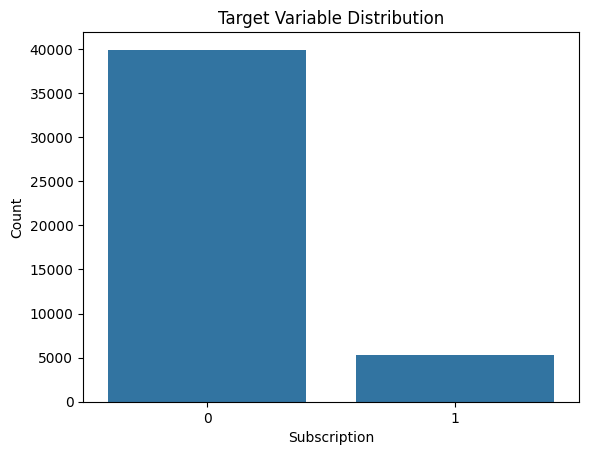

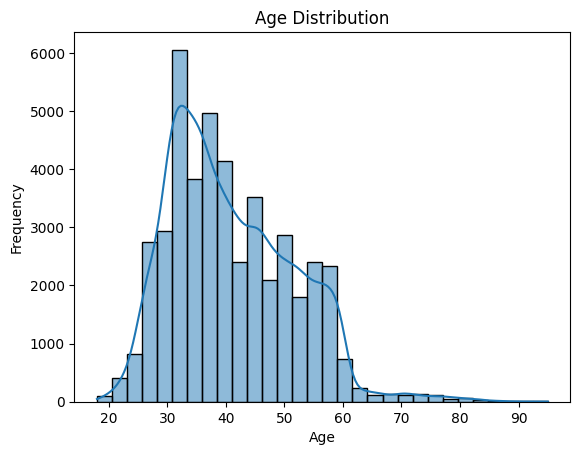

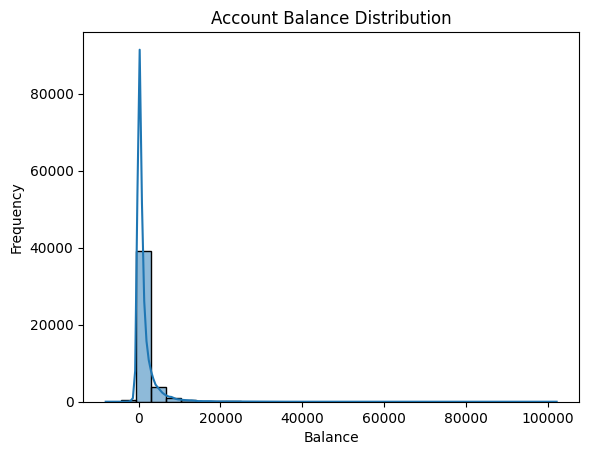

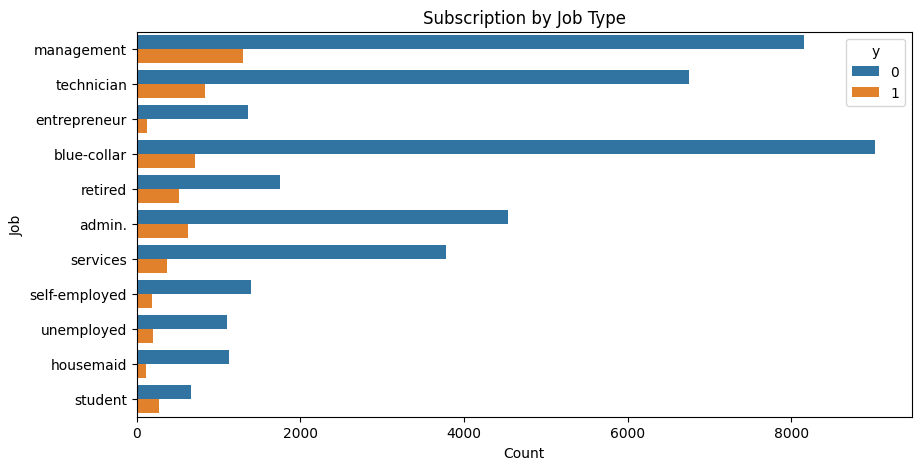

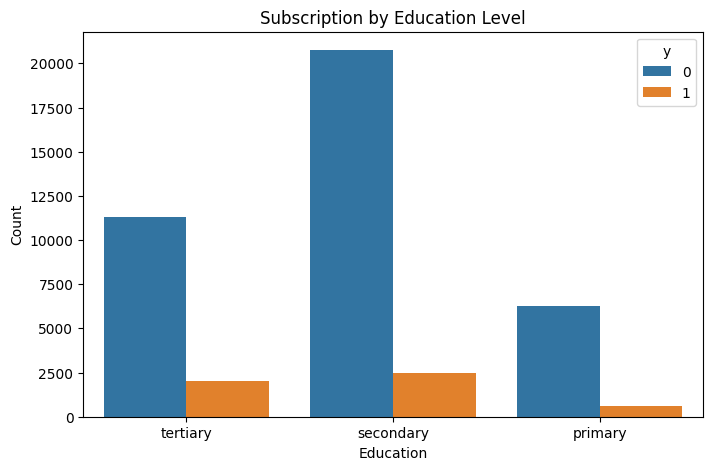

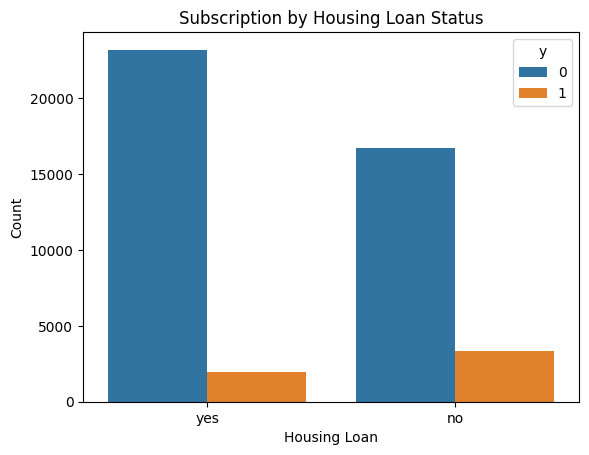

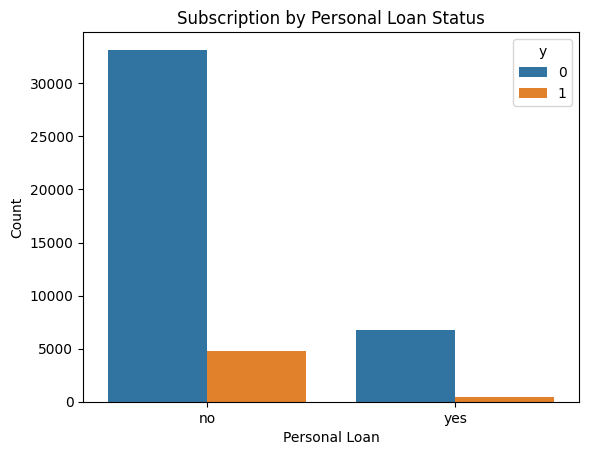

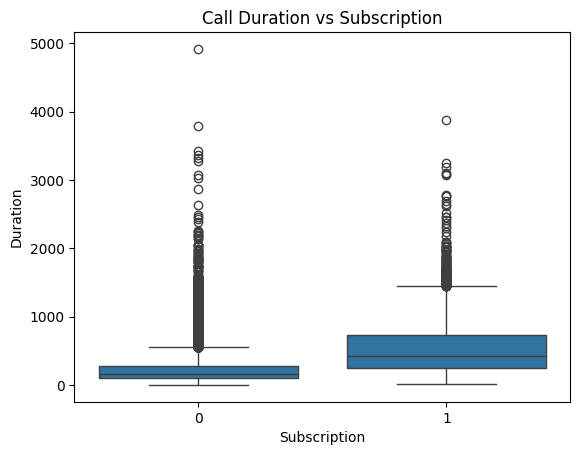

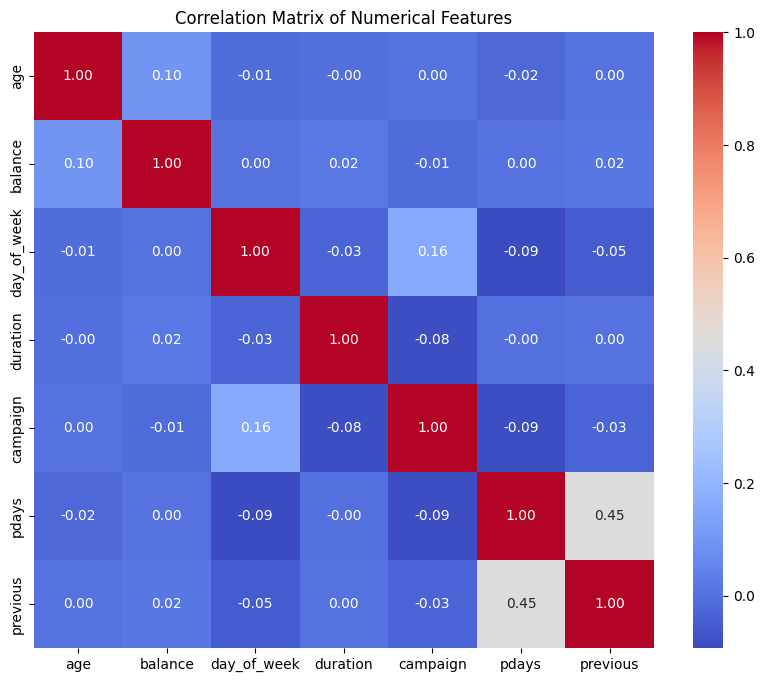

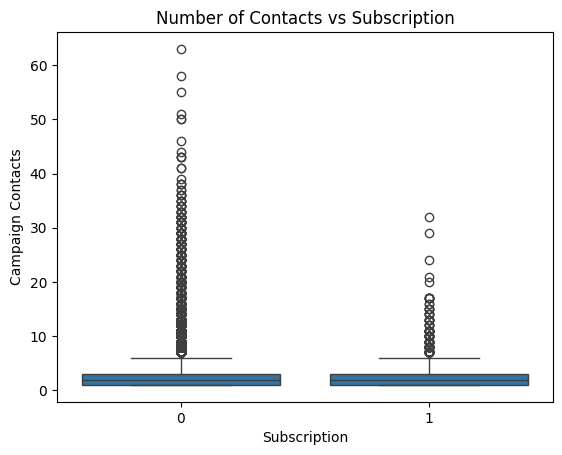

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine features and target for EDA
eda_df = X.copy()
eda_df['y'] = y['y']

# Basic dataset information
print("Dataset shape:")
print(eda_df.shape)

print("\nDataset info:")
print(eda_df.info())

print("\nStatistical summary for numerical variables:")
print(eda_df.describe())

# Target distribution
print("\nTarget variable distribution:")
print(eda_df['y'].value_counts())

plt.figure()
sns.countplot(x='y', data=eda_df)
plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

# Age distribution
plt.figure()
sns.histplot(eda_df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Balance distribution
plt.figure()
sns.histplot(eda_df['balance'], bins=30, kde=True)
plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

# Subscription by job
plt.figure(figsize=(10, 5))
sns.countplot(y='job', hue='y', data=eda_df)
plt.title("Subscription by Job Type")
plt.xlabel("Count")
plt.ylabel("Job")
plt.show()

# Subscription by education
plt.figure(figsize=(8, 5))
sns.countplot(x='education', hue='y', data=eda_df)
plt.title("Subscription by Education Level")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

# Subscription by housing loan
plt.figure()
sns.countplot(x='housing', hue='y', data=eda_df)
plt.title("Subscription by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Count")
plt.show()

# Subscription by personal loan
plt.figure()
sns.countplot(x='loan', hue='y', data=eda_df)
plt.title("Subscription by Personal Loan Status")
plt.xlabel("Personal Loan")
plt.ylabel("Count")
plt.show()

# Contact duration vs subscription
plt.figure()
sns.boxplot(x='y', y='duration', data=eda_df)
plt.title("Call Duration vs Subscription")
plt.xlabel("Subscription")
plt.ylabel("Duration")
plt.show()

# Correlation matrix for numerical features
numerical_features = eda_df.select_dtypes(include=['int64']).drop(columns=['y'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_features.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Campaign contacts vs subscription
plt.figure()
sns.boxplot(x='y', y='campaign', data=eda_df)
plt.title("Number of Contacts vs Subscription")
plt.xlabel("Subscription")
plt.ylabel("Campaign Contacts")
plt.show()

# Machine Learning

## Logistic Regression

Evaluation Metrics
Accuracy: 0.8387
Precision: 0.4031
Recall: 0.7883
F1 Score: 0.5334

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.97      0.85      0.90      7985
           1       0.40      0.79      0.53      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043


Logistic Regression Confusion Matrix
[[6750 1235]
 [ 224  834]]

Top 10 Most Important Features from Logistic Regression
             feature  coefficient  absolute_importance
39         month_mar     1.834472             1.834472
46  poutcome_success     1.654133             1.654133
3           duration     1.494974             1.494974
42         month_oct     1.260607             1.260607
40         month_may    -1.105786             1.105786
36         month_jan    -1.094096             1.094096
43         month_sep     0.969802    

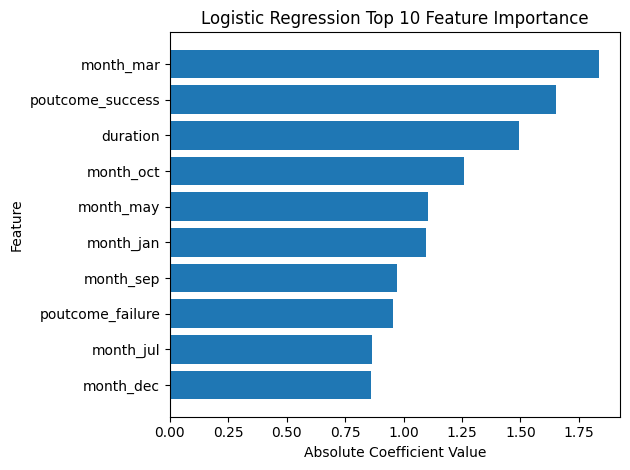

In [5]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression Training
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train_processed, y_train['y'])

y_pred_lr = lr_model.predict(X_test_processed)

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_lr), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_lr), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_lr), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_lr), 4))

print("\nLogistic Regression Classification Report")
print(classification_report(y_test['y'], y_pred_lr))

# Confusion Matrix
print("\nLogistic Regression Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_lr))

# Feature Names After Preprocessing
num_features_lr = numerical_cols

cat_features_lr = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)

feature_names_lr = np.concatenate([num_features_lr, cat_features_lr])

# Feature Importance Extraction
lr_coefficients = lr_model.coef_[0]

lr_importance_df = pd.DataFrame({
    'feature': feature_names_lr,
    'coefficient': lr_coefficients,
    'absolute_importance': np.abs(lr_coefficients)
}).sort_values(by='absolute_importance', ascending=False)

print("\nTop 10 Most Important Features from Logistic Regression")
print(lr_importance_df.head(10))

# Feature Importance Plot
top_lr_features = lr_importance_df.head(10)

plt.figure()
plt.barh(top_lr_features['feature'], top_lr_features['absolute_importance'])
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.title("Logistic Regression Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Random Forest Classifier

Evaluation Metrics
Accuracy: 0.9031
Precision: 0.6813
Recall: 0.3233
F1 Score: 0.4385

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.68      0.32      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.65      0.69      9043
weighted avg       0.89      0.90      0.89      9043


Random Forest Confusion Matrix
[[7825  160]
 [ 716  342]]

Top 10 Most Important Features from Random Forest
             feature  importance
3           duration    0.346414
1            balance    0.082187
0                age    0.079078
2        day_of_week    0.070611
4           campaign    0.036308
5              pdays    0.035592
46  poutcome_success    0.028141
44  poutcome_failure    0.023279
6           previous    0.023025
26        housing_no    0.020228


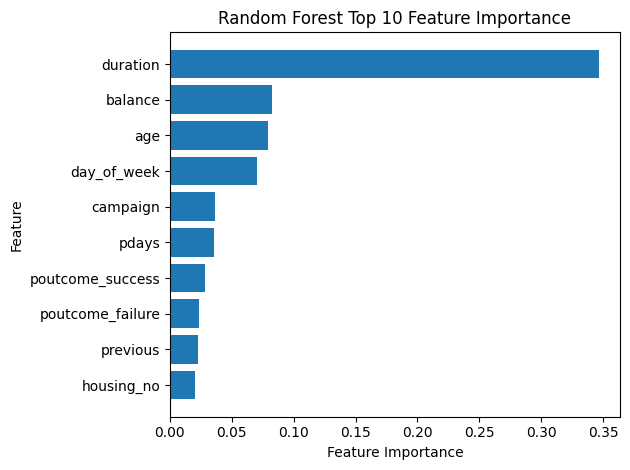

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Training
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_processed, y_train['y'])

y_pred_rf = rf_model.predict(X_test_processed)

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_rf), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_rf), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_rf), 4))

print("\nRandom Forest Classification Report")
print(classification_report(y_test['y'], y_pred_rf))

# Confusion Matrix
print("\nRandom Forest Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_rf))

# Feature Importance Extraction
rf_importance_df = pd.DataFrame({
    'feature': feature_names_lr,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from Random Forest")
print(rf_importance_df.head(10))

# Feature Importance Plot
top_rf_features = rf_importance_df.head(10)

plt.figure()
plt.barh(top_rf_features['feature'], top_rf_features['importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Support Vector Machine (SVM)

Evaluation Metrics
Accuracy: 0.8447
Precision: 0.4125
Recall: 0.7713
F1 Score: 0.5375

SVM Classification Report
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.41      0.77      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.81      0.72      9043
weighted avg       0.90      0.84      0.86      9043


SVM Confusion Matrix
[[6823 1162]
 [ 242  816]]

Top 10 Most Important Features from SVM
             feature  coefficient  absolute_importance
39         month_mar     0.672089             0.672089
46  poutcome_success     0.562598             0.562598
3           duration     0.488885             0.488885
42         month_oct     0.450857             0.450857
36         month_jan    -0.406808             0.406808
40         month_may    -0.378378             0.378378
43         month_sep     0.352243             0.352243
34         month_dec     0.334

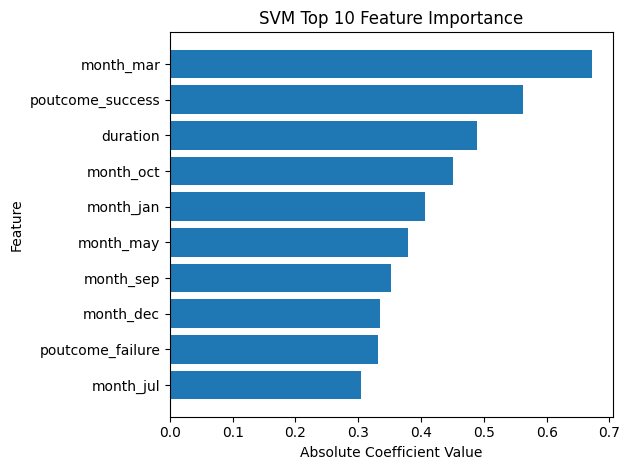

In [7]:
from sklearn.svm import LinearSVC

# Linear SVM Training
svm_model = LinearSVC(
    class_weight='balanced',
    max_iter=3000,
    random_state=42
)

svm_model.fit(X_train_processed, y_train['y'])

y_pred_svm = svm_model.predict(X_test_processed)

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_svm), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_svm), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_svm), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_svm), 4))

print("\nSVM Classification Report")
print(classification_report(y_test['y'], y_pred_svm))

# Confusion Matrix
print("\nSVM Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_svm))

# Feature Importance From Coefficients
svm_coefficients = svm_model.coef_[0]

svm_importance_df = pd.DataFrame({
    'feature': feature_names_lr,
    'coefficient': svm_coefficients,
    'absolute_importance': np.abs(svm_coefficients)
}).sort_values(by='absolute_importance', ascending=False)

print("\nTop 10 Most Important Features from SVM")
print(svm_importance_df.head(10))

# Feature Importance Plot
top_svm_features = svm_importance_df.head(10)

plt.figure()
plt.barh(top_svm_features['feature'], top_svm_features['absolute_importance'])
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.title("SVM Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Multi Layer Perceptron Neural Network

Evaluation Metrics
Accuracy: 0.8872
Precision: 0.5189
Recall: 0.4934
F1 Score: 0.5058

Neural Network Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7985
           1       0.52      0.49      0.51      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.72      0.72      9043
weighted avg       0.88      0.89      0.89      9043


Neural Network Confusion Matrix
[[7501  484]
 [ 536  522]]

Top 10 Most Important Features from Neural Network
             feature  importance
3           duration    0.042243
2        day_of_week    0.038262
40         month_may    0.022050
35         month_feb    0.013989
41         month_nov    0.012120
46  poutcome_success    0.011567
33         month_aug    0.011501
5              pdays    0.010351
6           previous    0.010085
38         month_jun    0.009764


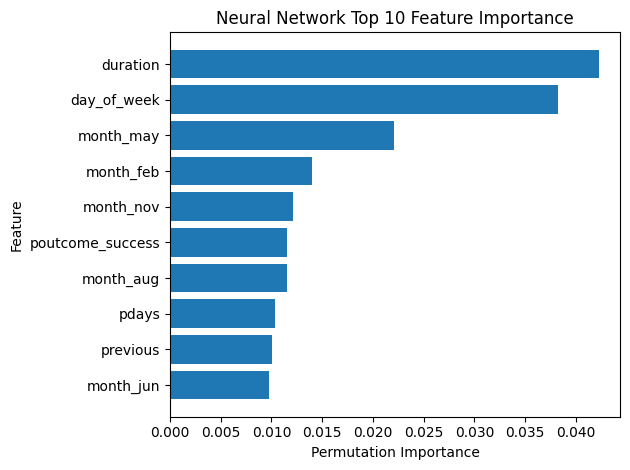

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

# MLP Training
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_processed, y_train['y'])

y_pred_mlp = mlp_model.predict(X_test_processed)

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_mlp), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_mlp), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_mlp), 4))

print("\nNeural Network Classification Report")
print(classification_report(y_test['y'], y_pred_mlp))

# Confusion Matrix
print("\nNeural Network Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_mlp))

# Feature Importance Using Permutation
mlp_perm = permutation_importance(
    mlp_model,
    X_test_processed,
    y_test['y'],
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

mlp_importance_df = pd.DataFrame({
    'feature': feature_names_lr,
    'importance': mlp_perm.importances_mean
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from Neural Network")
print(mlp_importance_df.head(10))

# Feature Importance Plot
top_mlp_features = mlp_importance_df.head(10)

plt.figure()
plt.barh(top_mlp_features['feature'], top_mlp_features['importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Neural Network Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Gradient Boosting Classifier

Evaluation Metrics
Accuracy: 0.9072
Precision: 0.6627
Recall: 0.4216
F1 Score: 0.5153

Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.66      0.42      0.52      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.70      0.73      9043
weighted avg       0.90      0.91      0.90      9043


Gradient Boosting Confusion Matrix
[[7758  227]
 [ 612  446]]

Top 10 Most Important Features from Gradient Boosting
             feature  importance
3           duration    0.465693
46  poutcome_success    0.173777
5              pdays    0.050048
0                age    0.041971
2        day_of_week    0.035857
39         month_mar    0.032495
26        housing_no    0.031580
42         month_oct    0.021986
32         month_apr    0.020239
27       housing_yes    0.019398


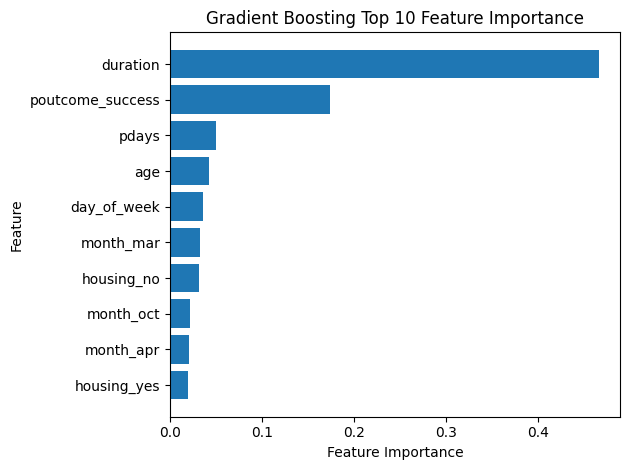

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting Training
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_processed, y_train['y'])

y_pred_gb = gb_model.predict(X_test_processed)

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_gb), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_gb), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_gb), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_gb), 4))

print("\nGradient Boosting Classification Report")
print(classification_report(y_test['y'], y_pred_gb))

# Confusion Matrix
print("\nGradient Boosting Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_gb))

# Feature Importance Extraction
gb_importance_df = pd.DataFrame({
    'feature': feature_names_lr,
    'importance': gb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from Gradient Boosting")
print(gb_importance_df.head(10))

# Feature Importance Plot
top_gb_features = gb_importance_df.head(10)

plt.figure()
plt.barh(top_gb_features['feature'], top_gb_features['importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## K-Nearest Neighbours

Evaluation Metrics
Accuracy: 0.8967
Precision: 0.6054
Recall: 0.3365
F1 Score: 0.4326

KNN Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.61      0.34      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043


KNN Confusion Matrix
[[7753  232]
 [ 702  356]]

Top 10 Most Important Features from KNN (Permutation Importance)
              feature  importance
3            duration    0.027259
5               pdays    0.006635
2         day_of_week    0.004810
6            previous    0.003539
46   poutcome_success    0.002875
44   poutcome_failure    0.002433
36          month_jan    0.001327
38          month_jun    0.001272
0                 age    0.001051
13  job_self-employed    0.000885


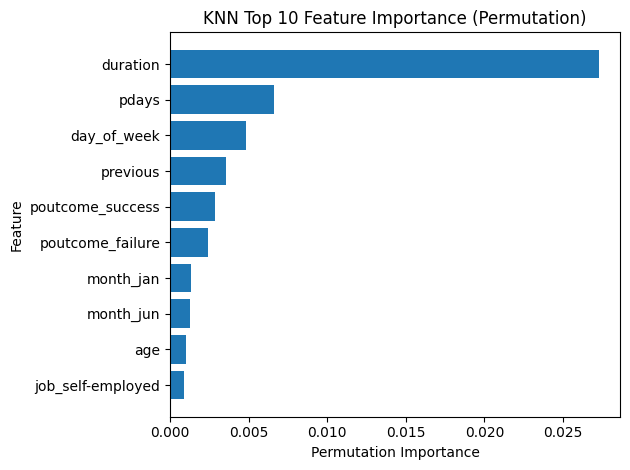

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance

# k-Nearest Neighbours Training
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski'
)

knn_model.fit(X_train_processed, y_train['y'])

y_pred_knn = knn_model.predict(X_test_processed)

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_knn), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_knn), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_knn), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_knn), 4))

print("\nKNN Classification Report")
print(classification_report(y_test['y'], y_pred_knn))

# Confusion Matrix
print("\nKNN Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_knn))

# Permutation Importance for KNN
perm_importance_knn = permutation_importance(
    knn_model,
    X_test_processed,
    y_test['y'],
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

knn_importance_df = pd.DataFrame({
    'feature': feature_names_lr,
    'importance': perm_importance_knn.importances_mean
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from KNN (Permutation Importance)")
print(knn_importance_df.head(10))

# Plot Top 10 Features
top_knn_features = knn_importance_df.head(10)

plt.figure()
plt.barh(top_knn_features['feature'], top_knn_features['importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("KNN Top 10 Feature Importance (Permutation)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Naive Bayes

Evaluation Metrics
Accuracy: 0.8519
Precision: 0.3946
Recall: 0.4972
F1 Score: 0.44

Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      7985
           1       0.39      0.50      0.44      1058

    accuracy                           0.85      9043
   macro avg       0.66      0.70      0.68      9043
weighted avg       0.87      0.85      0.86      9043


Naive Bayes Confusion Matrix
[[7178  807]
 [ 532  526]]

Top 10 Most Important Features from Naive Bayes (Permutation Importance)
             feature  importance
46  poutcome_success    0.024660
3           duration    0.012772
42         month_oct    0.009344
39         month_mar    0.008183
43         month_sep    0.007851
15       job_student    0.005971
34         month_dec    0.002046
32         month_apr    0.001382
20    marital_single    0.001161
19   marital_married    0.000995


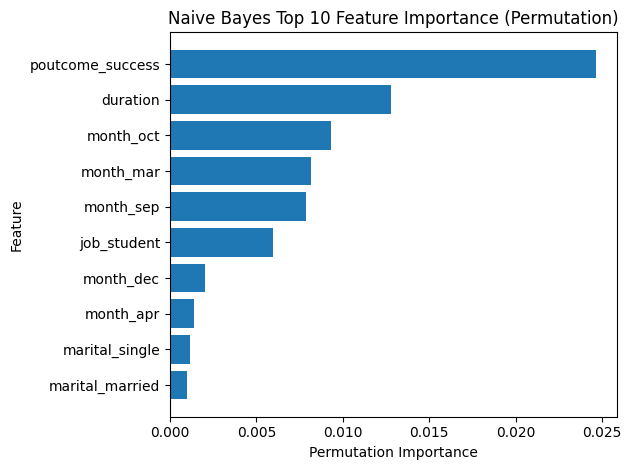

In [13]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes Training
nb_model = GaussianNB()

nb_model.fit(X_train_processed, y_train['y'])

y_pred_nb = nb_model.predict(X_test_processed)

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_nb), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_nb), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_nb), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_nb), 4))

print("\nNaive Bayes Classification Report")
print(classification_report(y_test['y'], y_pred_nb))

# Confusion Matrix
print("\nNaive Bayes Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_nb))

# Permutation Importance for Naive Bayes
perm_importance_nb = permutation_importance(
    nb_model,
    X_test_processed,
    y_test['y'],
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

nb_importance_df = pd.DataFrame({
    'feature': feature_names_lr,
    'importance': perm_importance_nb.importances_mean
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from Naive Bayes (Permutation Importance)")
print(nb_importance_df.head(10))

# Plot Top 10 Features
top_nb_features = nb_importance_df.head(10)

plt.figure()
plt.barh(top_nb_features['feature'], top_nb_features['importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Naive Bayes Top 10 Feature Importance (Permutation)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Model Comparison

Model Performance Comparison Table
                    Model  Accuracy  Precision  Recall  F1 Score
0     Logistic Regression    0.8387     0.4031  0.7883    0.5334
1           Random Forest    0.9031     0.6813  0.3233    0.4385
2  Support Vector Machine    0.8447     0.4125  0.7713    0.5375
3          Neural Network    0.8872     0.5189  0.4934    0.5058
4       Gradient Boosting    0.9072     0.6627  0.4216    0.5153
5    K Nearest Neighbours    0.8967     0.6054  0.3365    0.4326
6             Naive Bayes    0.8519     0.3946  0.4972    0.4400


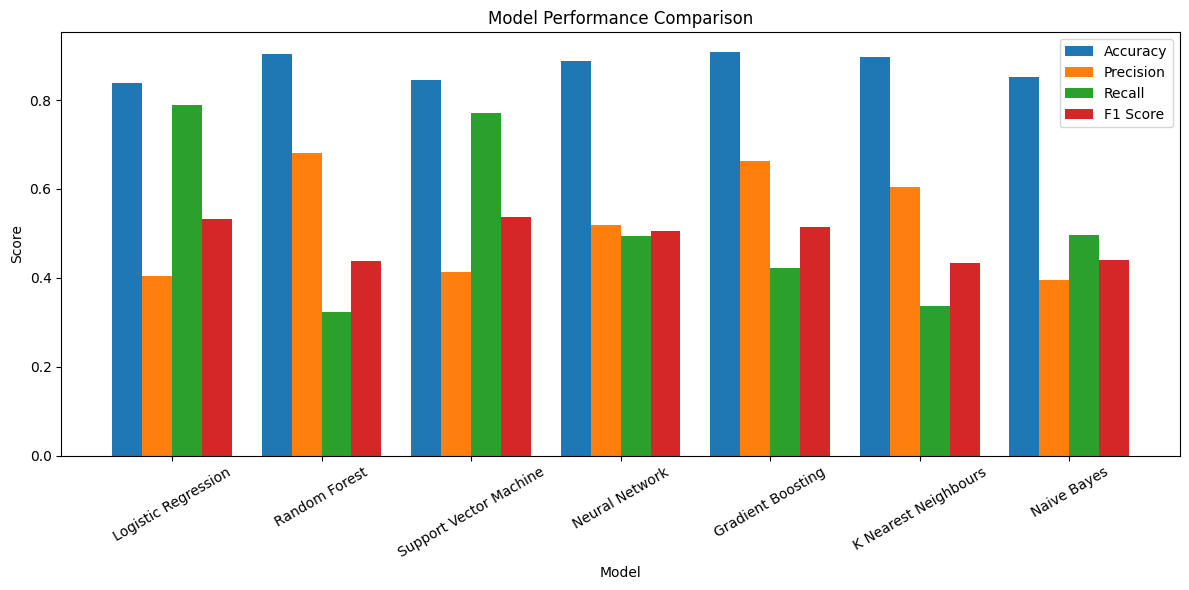

In [14]:
# Create metrics comparison table
metrics_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine',
        'Neural Network',
        'Gradient Boosting',
        'K Nearest Neighbours',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_score(y_test['y'], y_pred_lr),
        accuracy_score(y_test['y'], y_pred_rf),
        accuracy_score(y_test['y'], y_pred_svm),
        accuracy_score(y_test['y'], y_pred_mlp),
        accuracy_score(y_test['y'], y_pred_gb),
        accuracy_score(y_test['y'], y_pred_knn),
        accuracy_score(y_test['y'], y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test['y'], y_pred_lr),
        precision_score(y_test['y'], y_pred_rf),
        precision_score(y_test['y'], y_pred_svm),
        precision_score(y_test['y'], y_pred_mlp),
        precision_score(y_test['y'], y_pred_gb),
        precision_score(y_test['y'], y_pred_knn),
        precision_score(y_test['y'], y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test['y'], y_pred_lr),
        recall_score(y_test['y'], y_pred_rf),
        recall_score(y_test['y'], y_pred_svm),
        recall_score(y_test['y'], y_pred_mlp),
        recall_score(y_test['y'], y_pred_gb),
        recall_score(y_test['y'], y_pred_knn),
        recall_score(y_test['y'], y_pred_nb)
    ],
    'F1 Score': [
        f1_score(y_test['y'], y_pred_lr),
        f1_score(y_test['y'], y_pred_rf),
        f1_score(y_test['y'], y_pred_svm),
        f1_score(y_test['y'], y_pred_mlp),
        f1_score(y_test['y'], y_pred_gb),
        f1_score(y_test['y'], y_pred_knn),
        f1_score(y_test['y'], y_pred_nb)
    ]
})

# Round values for presentation
metrics_df.iloc[:, 1:] = metrics_df.iloc[:, 1:].round(4)

print("Model Performance Comparison Table")
print(metrics_df)

# Set data
models = metrics_df['Model']
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5*width, metrics_df['Accuracy'], width, label='Accuracy')
plt.bar(x - 0.5*width, metrics_df['Precision'], width, label='Precision')
plt.bar(x + 0.5*width, metrics_df['Recall'], width, label='Recall')
plt.bar(x + 1.5*width, metrics_df['F1 Score'], width, label='F1 Score')

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x, models, rotation=30)
plt.legend()
plt.tight_layout()
plt.show()